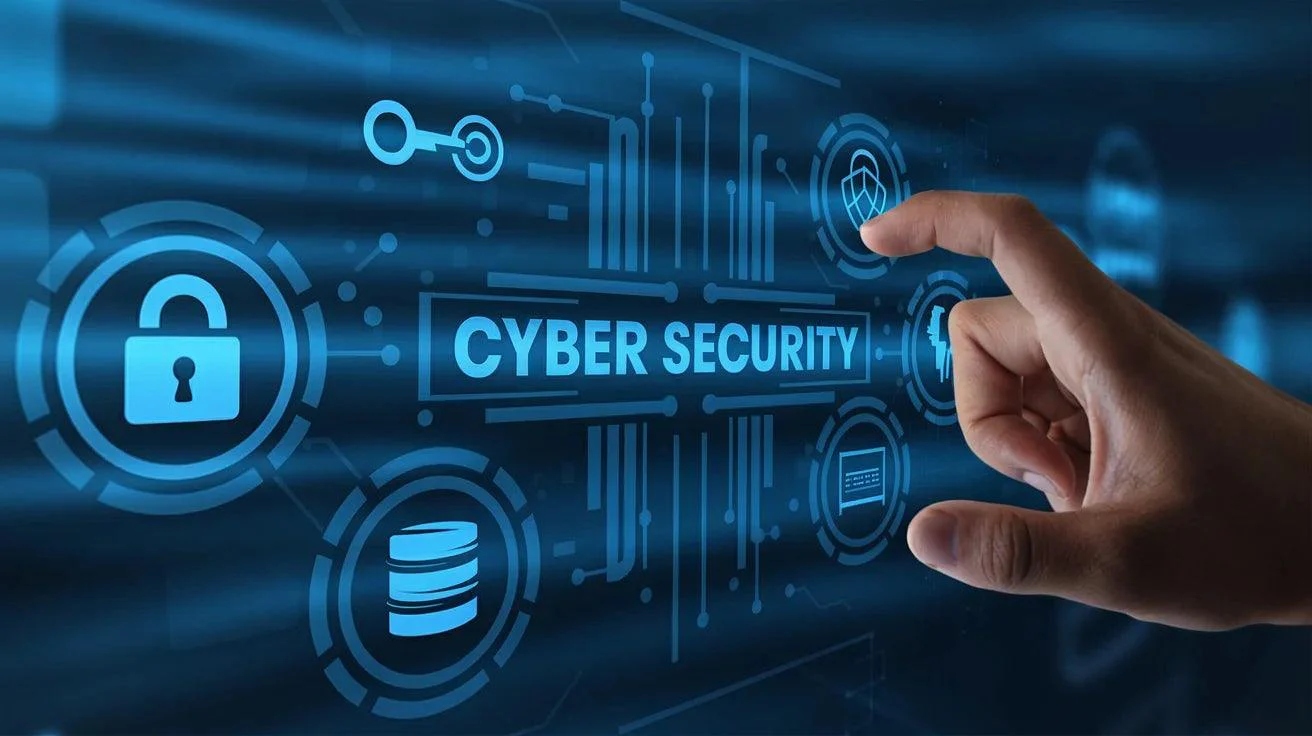

# **Cybersecurity Network Traffic Dataset: Baseline**

This dataset contains **network traffic records used for cybersecurity analysis**, specifically focused on detecting **Distributed Denial of Service (DDoS) and network flooding attacks**.  
Each CSV file represents traffic captured during a **specific attack type or normal network behavior**.


The dataset is divided into multiple CSV files, each corresponding to a specific attack category or normal traffic type.

| File | Description |
|-----|-------------|
| `DrDoS_DNS.csv` | DNS amplification Distributed Reflection Denial of Service attack traffic |
| `DrDoS_LDAP.csv` | LDAP reflection DDoS attack traffic |
| `DrDoS_MSSQL.csv` | MSSQL reflection DDoS attack traffic |
| `DrDoS_NetBIOS.csv` | NetBIOS reflection DDoS attack traffic |
| `DrDoS_NTP.csv` | NTP amplification attack traffic |
| `DrDoS_SNMP.csv` | SNMP reflection DDoS attack traffic |
| `DrDoS_SSDP.csv` | SSDP reflection DDoS attack traffic |
| `DrDoS_UDP.csv` | UDP flood distributed denial of service traffic |
| `Syn.csv` | SYN flood attack traffic |

These attack types are examples of volumetric or reflection-based DDoS attacks, where attackers overwhelm a server or network by generating massive traffic.

For training, we only consider the following CSV files due to limited computational resources. These CSV files were selected because these traffic types are commonly associated with reflection and amplification attacks. In these attacks, the attacker sends spoofed requests to legitimate servers (such as DNS, LDAP, or NTP services). The source IP address is forged to appear as the victim's address. As a result, the legitimate server sends the response to the victim instead of the attacker. Therefore, the analysis will focus on the following datasets:

- **DNS.csv**
- **LDAP.csv**
- **NTP.csv**
- **Syn.csv**



### **00 Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
import time
import json
import os

In [2]:
def confusion_matrix_heatmap(
    y_true,
    y_pred,
    model_name="Model",
    normalize=False,
    figsize=(7, 6),
    dpi=600
):
    """
    Generates and saves a publication-quality confusion matrix heatmap.

    Parameters
    ----------
    y_true : array-like
        Ground truth labels.

    y_pred : array-like
        Predicted labels.

    model_name : str
        Name used for plot title and export filename.

    normalize : bool
        If True, displays normalized percentages.

    figsize : tuple
        Figure size.

    dpi : int
        Export image quality.
    """

    # Create results/plots directory automatically
    save_dir = os.path.join("results", "plots")
    os.makedirs(save_dir, exist_ok=True)

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
        fmt = ".2f"
    else:
        fmt = "d"

    # Labels
    labels = ["No Attack", "Attack"]

    plt.style.use("seaborn-v0_8-white")

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        cbar=True,
        square=True,
        linewidths=1,
        linecolor="black",
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={
            "size": 13,
            "weight": "bold"
        },
        ax=ax
    )

    # Titles and labels
    ax.set_title(
        f"{model_name} Confusion Matrix",
        fontsize=16,
        weight="bold",
        pad=15
    )

    ax.set_xlabel(
        "Predicted Label",
        fontsize=13,
        weight="bold"
    )

    ax.set_ylabel(
        "True Label",
        fontsize=13,
        weight="bold"
    )

    # Tick formatting
    ax.tick_params(axis='both', labelsize=11)

    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    # Improve spacing
    plt.tight_layout()

    # Export paths
    png_path = os.path.join(
        save_dir,
        f"{model_name.lower().replace(' ', '_')}_confusion_matrix.png"
    )

    pdf_path = os.path.join(
        save_dir,
        f"{model_name.lower().replace(' ', '_')}_confusion_matrix.pdf"
    )

    # Save figures
    plt.savefig(
        png_path,
        dpi=dpi,
        bbox_inches="tight"
    )

    plt.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    print(f"Confusion matrix saved to:")
    print(f" - {png_path}")
    print(f" - {pdf_path}")

    plt.show()

### **01 Load Dataset**

The preprocessed dataset generated in the `02_Preprocessed.ipynb` notebook was loaded for the training phase.

After loading the dataset:

1. The target variable (`Label`) was separated from the feature set.
2. The label column was removed from the input features to avoid data leakage during training.
3. Feature scaling was applied using `StandardScaler`.

Standardization was performed to normalize the feature distributions and improve neural network convergence during training.

This preprocessing step ensures that all numerical features contribute proportionally during optimization and model training.

In [3]:
train_path = "preprocessed_data/train.csv"
val_path =  "preprocessed_data/val.csv"
test_path =  "preprocessed_data/test.csv"

In [4]:
train = pd.read_csv(train_path)
val = pd.read_csv(val_path)
test = pd.read_csv(test_path)

In [5]:
# Train
X_train = train.drop("Label", axis=1)
y_train = train["Label"]

# Validation
X_val = val.drop("Label", axis=1)
y_val = val["Label"]

# Test
X_test = test.drop("Label", axis=1)
y_test = test["Label"]

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# **1. Baseline Model**

A baseline neural network model was defined in order to establish a reference point for comparison with the Optuna multi-objective optimization process.

This baseline architecture was intentionally designed as a simple feedforward neural network with a fixed structure. The objective is to evaluate how much performance improvement can be achieved after hyperparameter optimization.

The model consists of:

- An input layer connected to:
  - A hidden layer with 32 neurons
  - A second hidden layer with 16 neurons
- A final output layer using a sigmoid activation function for binary classification

The sigmoid activation function was selected because the problem is formulated as a binary classification task, where the model predicts whether the network traffic corresponds to normal behavior or an attack.

The baseline architecture serves as the reference model against which the optimized Optuna-generated architectures are compared in terms of:

- F1-score
- Prediction time
- Overall classification performance






In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [8]:
def create_baseline_model(input_dim):

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

## **Baseline Architecture**

| **Layer** | **Configuration** |
|---|---|
| Hidden Layer 1 | 32 neurons |
| Hidden Layer 2 | 16 neurons |
| Output Layer | 1 neuron + Sigmoid |

In [9]:
model = create_baseline_model(X_train.shape[1])
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                2048      
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 1)                 17        
                                                                 
Total params: 2593 (10.13 KB)
Trainable params: 2593 (10.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [10]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=256,
    verbose=1
)

Epoch 1/20


98/98 [==============================] - 2s 5ms/step - loss: 0.2108 - accuracy: 0.9555 - auc: 0.9942 - val_loss: 0.0512 - val_accuracy: 0.9922 - val_auc: 0.9985
Epoch 2/20
98/98 [==============================] - 0s 2ms/step - loss: 0.0276 - accuracy: 0.9969 - auc: 0.9994 - val_loss: 0.0217 - val_accuracy: 0.9974 - val_auc: 0.9991
Epoch 3/20
98/98 [==============================] - 0s 2ms/step - loss: 0.0145 - accuracy: 0.9981 - auc: 0.9995 - val_loss: 0.0146 - val_accuracy: 0.9974 - val_auc: 0.9993
Epoch 4/20
98/98 [==============================] - 0s 2ms/step - loss: 0.0101 - accuracy: 0.9982 - auc: 0.9996 - val_loss: 0.0113 - val_accuracy: 0.9976 - val_auc: 0.9996
Epoch 5/20
98/98 [==============================] - 0s 2ms/step - loss: 0.0079 - accuracy: 0.9983 - auc: 0.9996 - val_loss: 0.0103 - val_accuracy: 0.9976 - val_auc: 0.9994
Epoch 6/20
98/98 [==============================] - 0s 2ms/step - loss: 0.0071 - accuracy: 0.9986 - auc: 0.9997 - val_loss: 0.0094 - val_a

Proving with testing and time measurement

In [11]:
times = []

# Warmup
model.predict(
    X_test[:1],
    verbose=0
)

for _ in range(100):

    start = time.perf_counter()

    model.predict(
        X_test[:1],
        verbose=0
    )

    end = time.perf_counter()

    times.append(end - start)

# Average latency in milliseconds
baseline_inference_time_ms = float(
    np.mean(times) * 1000
)



In [12]:
y_pred_probs = model.predict(
    X_test,
    batch_size=4096,
    verbose=1
)

y_pred = (y_pred_probs > 0.5).astype(int).flatten()

print(
    f"Baseline Inference Time: "
    f"{baseline_inference_time_ms:.4f} ms/sample"
)

471/471 [==============================] - 1s 2ms/step
Baseline Inference Time: 65.1790 ms/sample


### **Metrics**

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", tf.keras.metrics.AUC()(y_test, y_pred_probs).numpy() )

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9989963175846093
Precision: 0.9999968799692989
Recall: 0.9989973932223782
F1 Score: 0.9994968867267492
AUC: 0.99971735

Confusion Matrix:
[[   3909       6]
 [   1930 1923052]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80      3915
           1       1.00      1.00      1.00   1924982

    accuracy                           1.00   1928897
   macro avg       0.83      1.00      0.90   1928897
weighted avg       1.00      1.00      1.00   1928897



### **Export Results in json format**

In [14]:
results = {

    "accuracy": float(
        accuracy_score(y_test, y_pred)
    ),

    "precision": float(
        precision_score(y_test, y_pred)
    ),

    "recall": float(
        recall_score(y_test, y_pred)
    ),

    "f1_score": float(
        f1_score(y_test, y_pred)
    ),

    "auc": float(
        tf.keras.metrics.AUC()(
            y_test,
            y_pred_probs
        ).numpy()
    ),

    "inference_time_ms": baseline_inference_time_ms,

    "confusion_matrix": confusion_matrix(
        y_test,
        y_pred
    ).tolist(),

    "classification_report": classification_report(
        y_test,
        y_pred,
        output_dict=True
    )
}



In [15]:
os.makedirs("results", exist_ok=True)

with open("results/evaluation_results_baseline.json", "w") as f:

    json.dump(
        results,
        f,
        indent=4
    )

print("Results exported to results/evaluation_results_baseline.json")

Results exported to results/evaluation_results_baseline.json


### **Confusion Matrix**

Confusion matrix saved to:
 - results\plots\model_confusion_matrix.png
 - results\plots\model_confusion_matrix.pdf


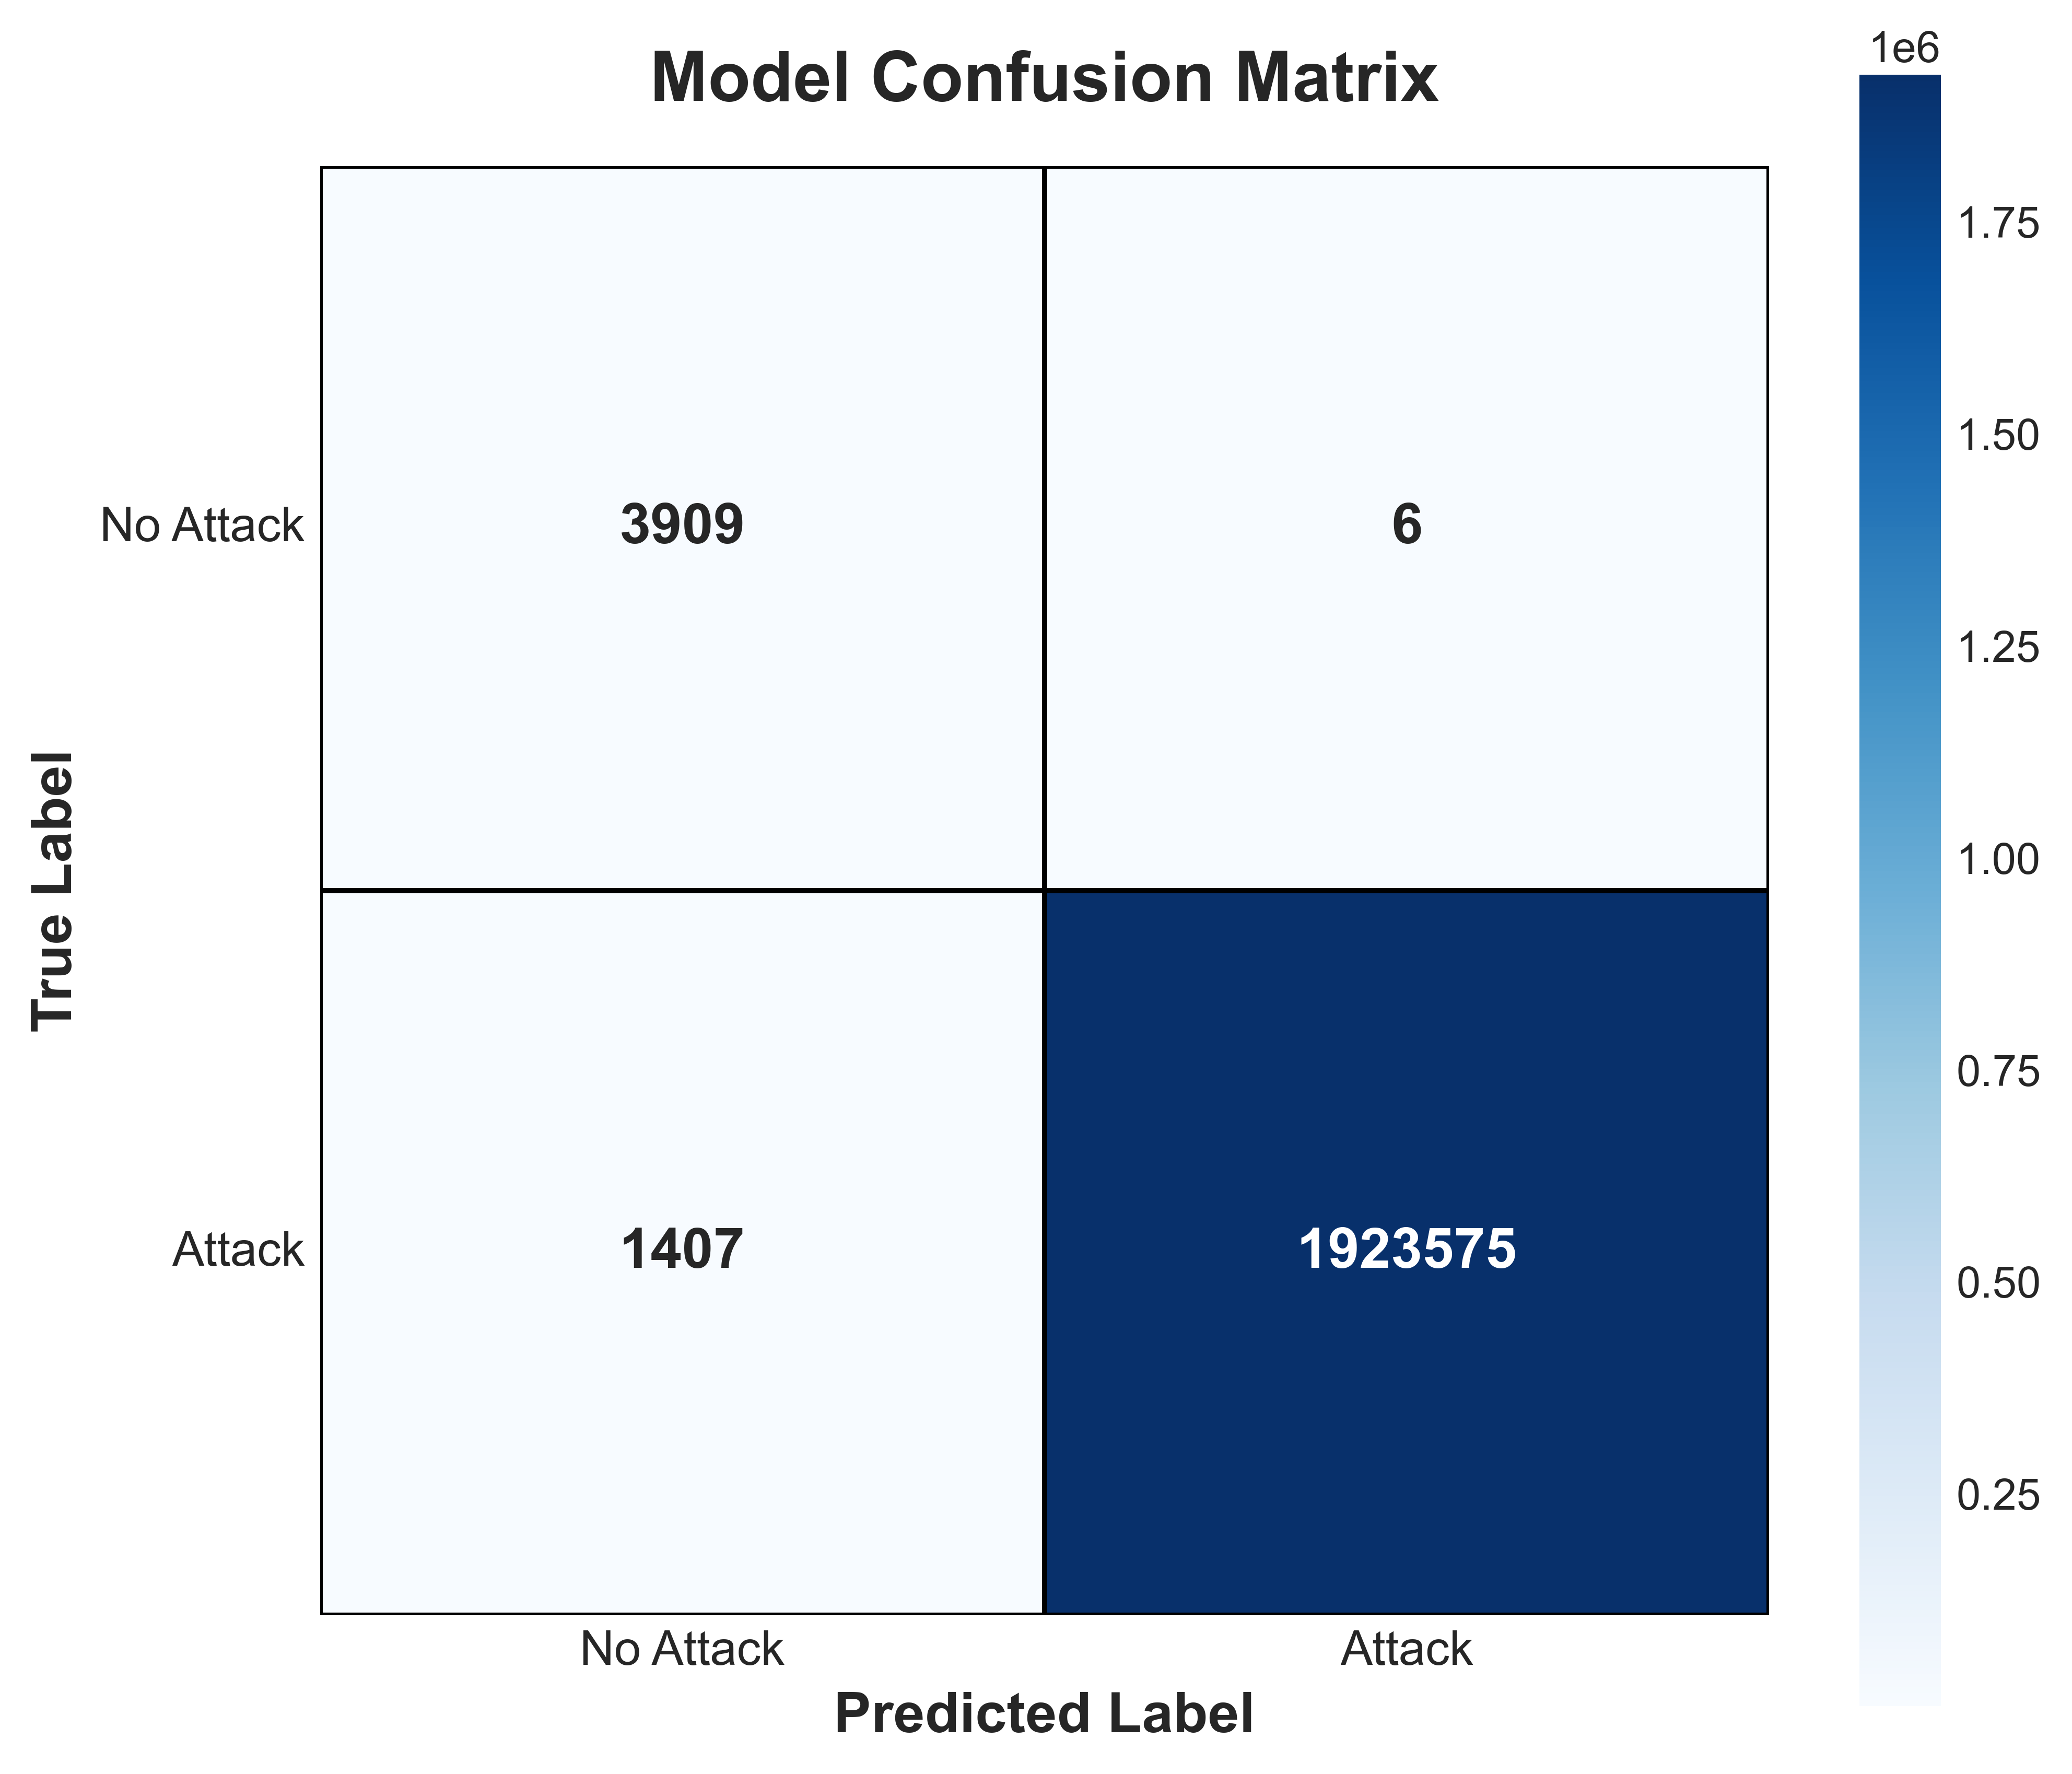

In [19]:
confusion_matrix_heatmap(y_test, y_pred)

# **2. Optuna Optimization**

To improve the performance of the baseline neural network, a multi-objective hyperparameter optimization process was implemented using **Optuna**. Optuna is an automatic hyperparameter optimization framework designed to efficiently explore large search spaces and identify optimal model configurations.

In this project, Optuna was used to optimize the neural network architecture and training parameters while simultaneously considering two objectives:

- Maximize the F1-score
- Minimize prediction time

This approach allows the identification of models that not only achieve high classification performance but also maintain low inference latency for real-time cybersecurity applications.

In [20]:
import sys
!{sys.executable} -m pip install plotly


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import sys
!{sys.executable} -m pip install optuna


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import time
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


### **Optimization Strategy**

The study was configured as a **multi-objective optimization problem**, where each trial generates a different neural network configuration.

For every trial, Optuna evaluates:

1. Neural network architecture
2. Learning rate
3. Batch size
4. Number of hidden layers
5. Hidden layer dimensions

The resulting model is then trained and evaluated using the validation dataset.

The following hyperparameters were explored during optimization:

| Hyperparameter | Search Range |
|---|---|
| Hidden layer size | 32 → 256 |
| Number of hidden layers | 1 → 5 |
| Learning rate | 1e-5 → 1e-2 |
| Batch size | 32, 64, 128 |



In [23]:
RANDOM_STATE = 42
N_TRIALS = 100
N_RUNS_TIMING = 10

# Hidden layer size range
HIDDEN_SIZE_MIN = 32
HIDDEN_SIZE_MAX = 256

# Number of hidden layers
NUM_LAYERS_MIN = 1
NUM_LAYERS_MAX = 5

# Learning rate range
LR_MIN = 1e-5
LR_MAX = 1e-2

# Batch size options
BATCH_SIZES = [32, 64, 128]

# Optimization directions
DIRECTIONS = ["maximize", "minimize"]

### **Multi-Objective Optimization**

The optimization process simultaneously evaluates:

| Objective | Goal |
|---|---|
| F1-score | Maximize |
| Prediction time | Minimize |

Because these objectives are conflicting, Optuna generates a **Pareto Front**, which contains the set of optimal trade-off solutions.

Some models may achieve:

- Higher classification accuracy with slower inference
- Faster prediction speed with slightly lower performance

This methodology allows selecting models according to system requirements and computational constraints.



In [24]:
def build_model(hidden_size, lr, num_layers):

    model = keras.Sequential()

    # Input layer + first hidden layer
    model.add(
        layers.Dense(
            hidden_size,
            activation="relu",
            input_shape=(X_train.shape[1],)
        )
    )

    # Additional hidden layers
    current_size = hidden_size

    for _ in range(num_layers - 1):

        # Optional progressive reduction
        current_size = max(current_size // 2, 16)

        model.add(
            layers.Dense(
                current_size,
                activation="relu"
            )
        )

    # Output layer
    model.add(
        layers.Dense(1, activation="sigmoid")
    )

    # Optimizer
    optimizer = keras.optimizers.Adam(
        learning_rate=lr
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [25]:
def train_and_evaluate(model, batch_size):

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=batch_size,
        verbose=0
    )

    # Predictions
    y_pred = model.predict(X_val, verbose=0)

    # Convert probabilities to binary labels
    y_pred = (y_pred > 0.5).astype(int).flatten()

    # F1-score
    f1 = f1_score(y_val, y_pred)

    # Validation loss
    val_loss = history.history["val_loss"][-1]

    return val_loss, f1

### **Prediction Time Evaluation**

Inference latency was incorporated as a second optimization objective in order to evaluate real-time applicability.

Prediction time was measured multiple times to reduce noise and variability:
The average prediction time across all runs was used during optimization.


In [26]:
import time
import numpy as np

def measure_inference_time(model, X_val, n_runs=N_RUNS_TIMING):
    # Single sample
    sample = X_val[:1]
    times = []

    # Warmup
    model.predict(sample, verbose=0)

    for _ in range(n_runs):
        start = time.perf_counter()
        model.predict(sample, verbose=0)
        end = time.perf_counter()
        times.append(end - start)

    return float(np.mean(times))

In [27]:
def objective(trial):

    # Hyperparameters
    hidden_size = trial.suggest_int(
        "hidden_size",
        HIDDEN_SIZE_MIN,
        HIDDEN_SIZE_MAX
    )

    num_layers = trial.suggest_int(
        "num_layers",
        NUM_LAYERS_MIN,
        NUM_LAYERS_MAX
    )

    lr = trial.suggest_float(
        "lr",
        LR_MIN,
        LR_MAX,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        BATCH_SIZES
    )

    # Build model
    model = build_model(
        hidden_size=hidden_size,
        lr=lr,
        num_layers=num_layers
    )

    # Train and evaluate
    val_loss, f1 = train_and_evaluate(
        model,
        batch_size
    )

    # Measure inference speed
    inference_time = measure_inference_time(
        model,
        X_val
    )

    # Multi-objective optimization
    return f1, inference_time

In [28]:
def create_study():

    study = optuna.create_study(
        directions=DIRECTIONS,
        sampler=optuna.samplers.NSGAIISampler(seed=RANDOM_STATE)
    )

    return study

### **Pareto Front Analysis**
In this project, the optimization process simultaneously attempts to:

- Maximize the F1-score
- Minimize prediction time

These objectives are inherently conflicting because more complex neural network architectures may achieve higher classification performance while also increasing computational cost and inference latency.
To analyze this trade-off, Optuna generates a **Pareto Front**.

A Pareto Front is the set of optimal solutions in a multi-objective optimization problem.
A solution belongs to the Pareto Front if:

- No other solution improves one objective without worsening the other.
- Its F1-score cannot be improved without increasing prediction time.
- Its prediction time cannot be reduced without decreasing F1-score.

These solutions represent the best trade-offs discovered during optimization.

###  **Pareto Dominance**

A model is said to dominate another model if:

- It achieves equal or better performance in all objectives
- And strictly better performance in at least one objective

The Pareto Front provides multiple optimal candidate models rather than a single “best” solution.

This allows selecting models depending on system requirements.
During Optuna optimization:

- Each trial generates a different neural network architecture.
- Each model is evaluated using:
  - F1-score
  - Prediction time

After all trials are completed, Optuna identifies the subset of non-dominated solutions.

These solutions form the Pareto Front.

The Pareto-optimal models represent the best balance between:

- Detection capability
- Computational efficiency

In [29]:
def print_pareto_front(study):

    pareto_trials = study.best_trials

    print(f"\nPareto-front trials: {len(pareto_trials)}")
    print("=" * 60)

    for t in pareto_trials:

        f1_score_val = t.values[0]
        inf_time_ms = t.values[1] * 1000

        print(
            f"Trial #{t.number:<3} | "
            f"F1-score: {f1_score_val:.4f} | "
            f"Inference Time: {inf_time_ms:.3f} ms"
        )

        print(f"Parameters: {t.params}")
        print("-" * 60)

In [30]:
def plot_pareto_front(study, save_path=None):

    pareto_trials = study.best_trials

    f1_scores = [t.values[0] for t in pareto_trials]

    inference_times = [
        t.values[1] * 1000
        for t in pareto_trials
    ]

    plt.figure(figsize=(7, 5), dpi=300)

    plt.scatter(
        inference_times,
        f1_scores,
        s=80,
        alpha=0.8
    )

    # Annotate each point with trial number
    for i, t in enumerate(pareto_trials):

        plt.annotate(
            f"T{t.number}",
            (inference_times[i], f1_scores[i]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

    plt.xlabel("Inference Time (ms)", fontsize=12)
    plt.ylabel("F1-score", fontsize=12)

    plt.title(
        "Pareto Front for Multi-Objective Optimization",
        fontsize=14,
        weight='bold'
    )

    plt.grid(True)

    plt.tight_layout()

    # Save publication-quality figure
    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches='tight'
        )

    plt.show()

### **Training Workflow**
Unlike the baseline model, the Optuna architecture is not fixed.
The number of layers and neurons is dynamically generated according to the sampled hyperparameters.
This allows the optimizer to explore multiple architectural combinations and identify efficient configurations.

For each Optuna trial:

1. A neural network architecture is generated dynamically.
2. Hyperparameters are sampled from the search space.
3. The model is trained using the balanced training dataset.
4. Validation metrics are computed.
5. Prediction time is measured multiple times.
6. Both objectives are returned to the optimizer.

The optimization process continues for a total of 100 trials.




In [31]:
study = create_study()

[I 2026-05-12 19:12:22,629] A new study created in memory with name: no-name-7438b396-6f3c-4677-9574-08bfcc24bf31


In [32]:
study.optimize(objective, n_trials=100)

[I 2026-05-12 19:12:54,192] Trial 0 finished with values: [0.9987236758136566, 0.13035870999883628] and parameters: {'hidden_size': 116, 'num_layers': 5, 'lr': 0.001570297088405539, 'batch_size': 32}.
[I 2026-05-12 19:13:05,883] Trial 1 finished with values: [0.9985634477254589, 0.1408582000018214] and parameters: {'hidden_size': 45, 'num_layers': 5, 'lr': 0.0006358358856676254, 'batch_size': 128}.
[I 2026-05-12 19:13:18,181] Trial 2 finished with values: [0.9974481658692185, 0.13194500999961747] and parameters: {'hidden_size': 219, 'num_layers': 2, 'lr': 3.511356313970405e-05, 'batch_size': 128}.
[I 2026-05-12 19:13:29,468] Trial 3 finished with values: [0.9987220447284345, 0.13930795999767726] and parameters: {'hidden_size': 129, 'num_layers': 2, 'lr': 0.000684792009557478, 'batch_size': 128}.
[I 2026-05-12 19:13:41,844] Trial 4 finished with values: [0.998084902649218, 0.04874141000036616] and parameters: {'hidden_size': 134, 'num_layers': 4, 'lr': 3.972110727381908e-05, 'batch_size

In [33]:
print_pareto_front(study)


Pareto-front trials: 5
Trial #10  | F1-score: 0.9994 | Inference Time: 58.296 ms
Parameters: {'hidden_size': 119, 'num_layers': 2, 'lr': 0.003063462210622081, 'batch_size': 128}
------------------------------------------------------------
Trial #12  | F1-score: 0.9989 | Inference Time: 48.161 ms
Parameters: {'hidden_size': 33, 'num_layers': 5, 'lr': 0.001319994226153501, 'batch_size': 64}
------------------------------------------------------------
Trial #24  | F1-score: 0.9987 | Inference Time: 46.896 ms
Parameters: {'hidden_size': 96, 'num_layers': 1, 'lr': 0.0006740513796374046, 'batch_size': 32}
------------------------------------------------------------
Trial #25  | F1-score: 0.9974 | Inference Time: 46.522 ms
Parameters: {'hidden_size': 236, 'num_layers': 2, 'lr': 2.7207248059486674e-05, 'batch_size': 64}
------------------------------------------------------------
Trial #61  | F1-score: 0.9992 | Inference Time: 58.071 ms
Parameters: {'hidden_size': 183, 'num_layers': 2, 'lr': 

In cybersecurity systems, achieving high classification accuracy is important, but inference speed is also critical.

A highly accurate model may become impractical if:

- Prediction latency is too high
- Real-time detection is required
- Computational resources are limited

The Pareto Front analysis allows selecting architectures that satisfy operational constraints while maintaining strong detection performance.

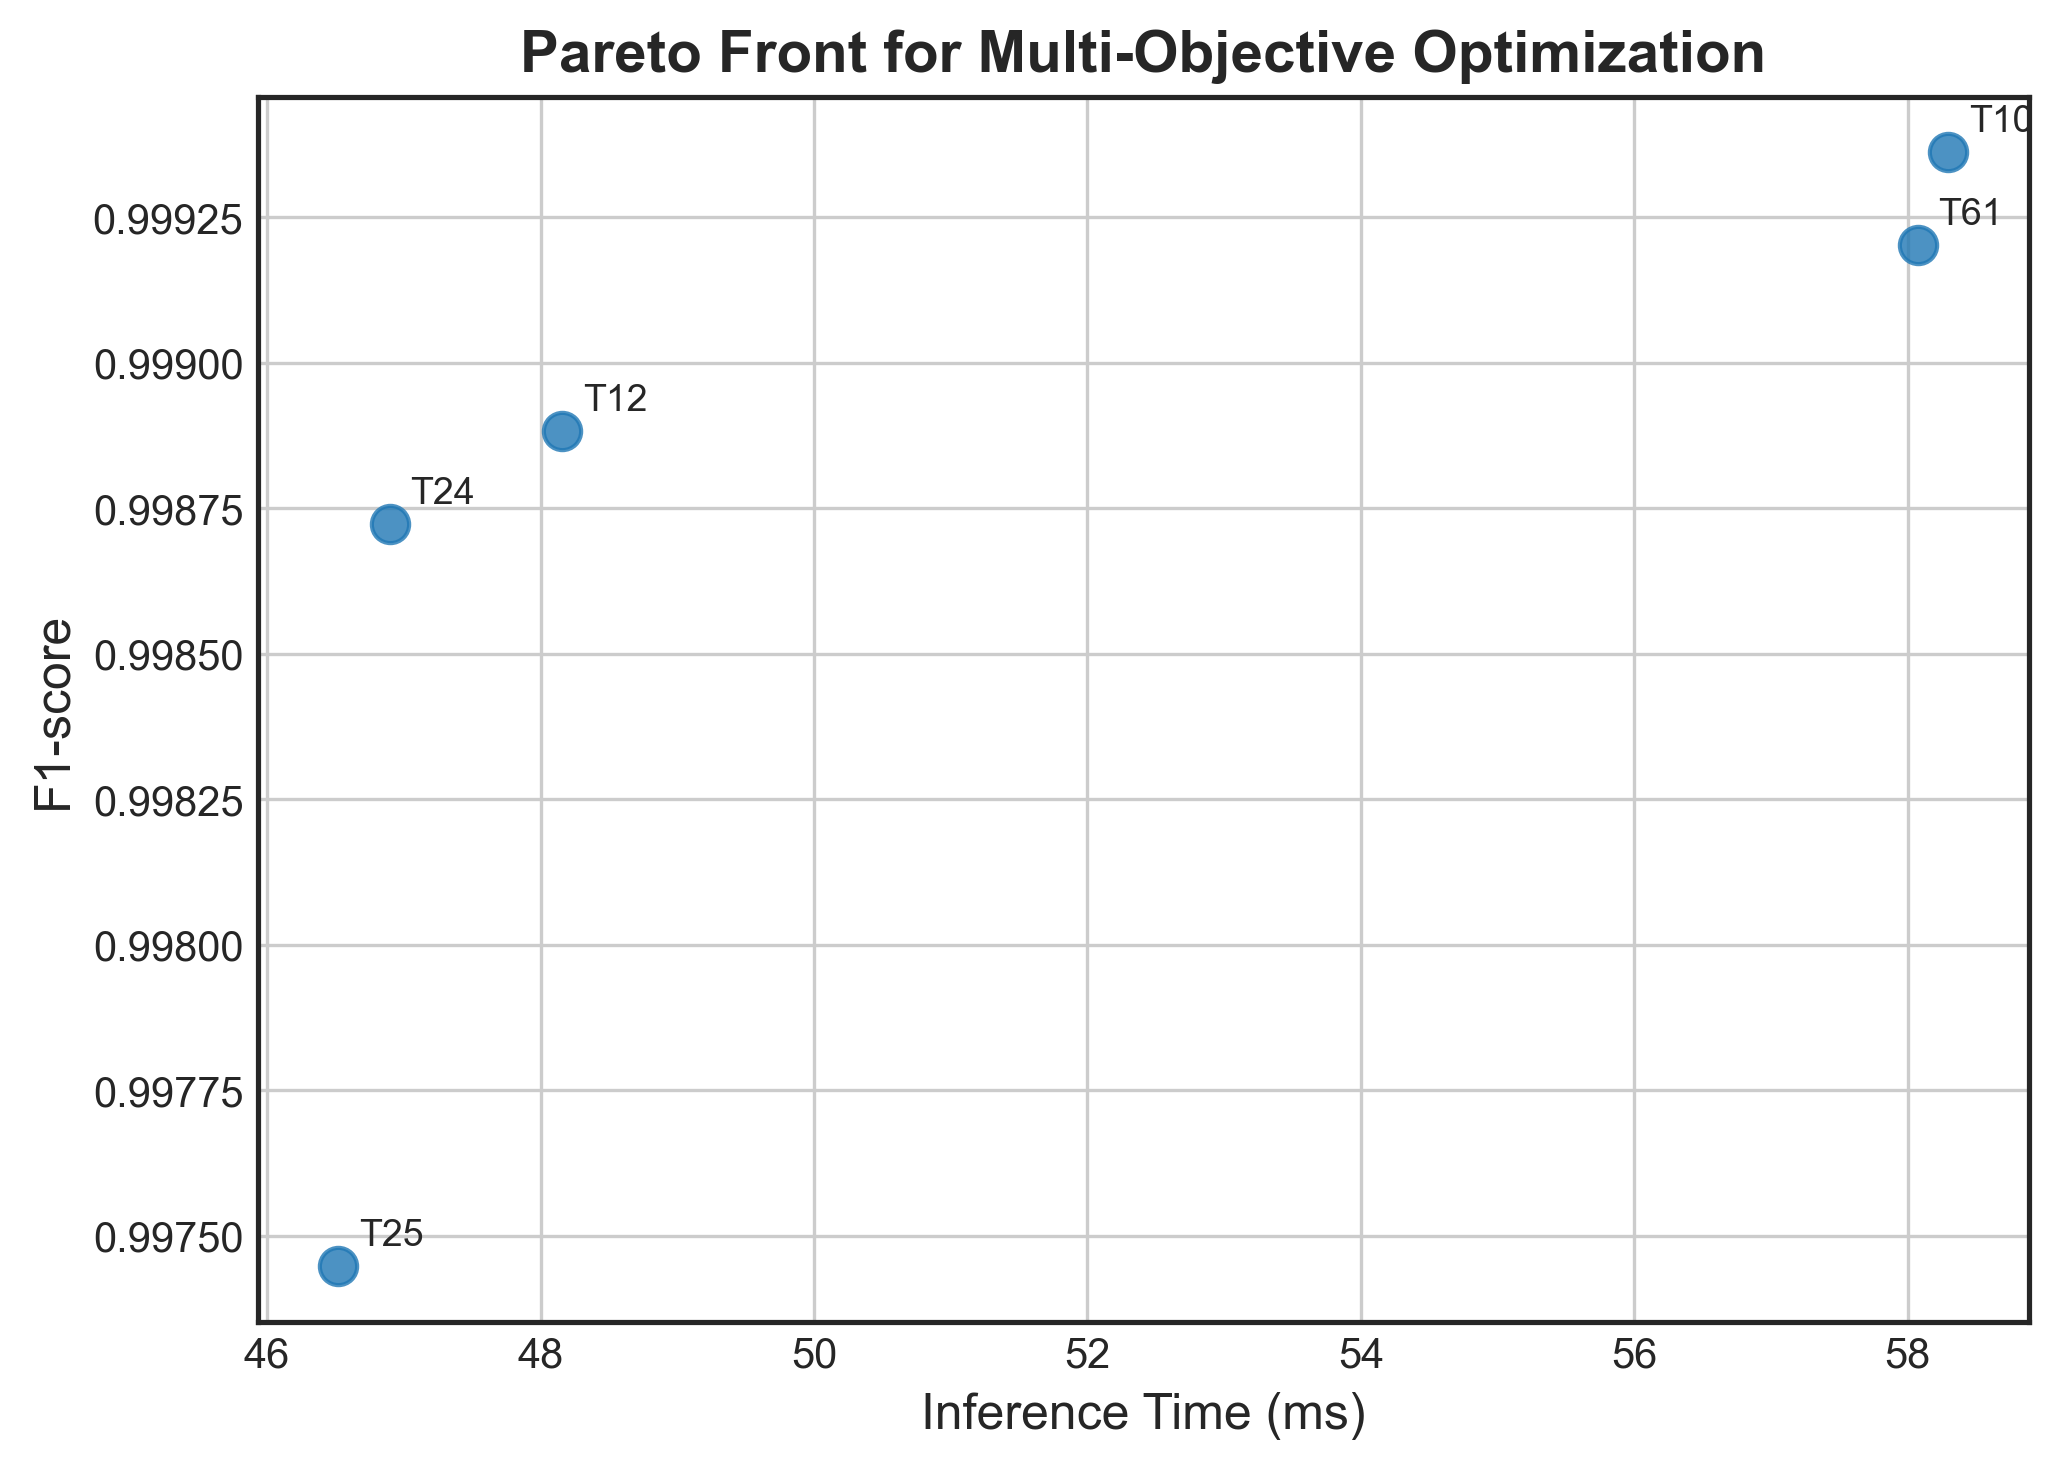

In [34]:
plot_pareto_front(study)

In [35]:
def pareto_dataframe(study):

    rows = []

    for t in study.best_trials:

        rows.append({
            "Trial": t.number,
            "F1-score": round(t.values[0], 4),
            "Inference Time (ms)": round(t.values[1] * 1000, 3),
            "Hidden Size": t.params["hidden_size"],
            "Num Layers": t.params["num_layers"],
            "Learning Rate": t.params["lr"],
            "Batch Size": t.params["batch_size"]
        })

    df = pd.DataFrame(rows)

    return df

In [36]:
df_pareto = pareto_dataframe(study)

print(df_pareto)

   Trial  F1-score  Inference Time (ms)  Hidden Size  Num Layers  \
0     10    0.9994               58.296          119           2   
1     12    0.9989               48.161           33           5   
2     24    0.9987               46.896           96           1   
3     25    0.9974               46.522          236           2   
4     61    0.9992               58.071          183           2   

   Learning Rate  Batch Size  
0       0.003063         128  
1       0.001320          64  
2       0.000674          32  
3       0.000027          64  
4       0.007321         128  


In [37]:
df_pareto.to_csv("pareto_results.csv", index=False)

In [38]:
best_trial = df_pareto.iloc[1]

# **4.Train Best Model**

In [39]:
best_params = best_trial

final_model = build_model(
    hidden_size=int(best_params["Hidden Size"]),
    lr=float(best_params["Learning Rate"]),
    num_layers=int(best_params["Num Layers"])
)

history = final_model.fit(
    X_train,
    y_train,
    batch_size=int(best_params["Batch Size"]),
    epochs=20,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/20
392/392 [==============================] - 2s 2ms/step - loss: 0.0549 - accuracy: 0.9899 - val_loss: 0.0134 - val_accuracy: 0.9974
Epoch 2/20
392/392 [==============================] - 1s 2ms/step - loss: 0.0073 - accuracy: 0.9984 - val_loss: 0.0078 - val_accuracy: 0.9981
Epoch 3/20
392/392 [==============================] - 1s 2ms/step - loss: 0.0057 - accuracy: 0.9986 - val_loss: 0.0064 - val_accuracy: 0.9986
Epoch 4/20
392/392 [==============================] - 1s 2ms/step - loss: 0.0046 - accuracy: 0.9988 - val_loss: 0.0065 - val_accuracy: 0.9981
Epoch 5/20
392/392 [==============================] - 1s 2ms/step - loss: 0.0040 - accuracy: 0.9990 - val_loss: 0.0061 - val_accuracy: 0.9987
Epoch 6/20
392/392 [==============================] - 1s 2ms/step - loss: 0.0044 - accuracy: 0.9986 - val_loss: 0.0062 - val_accuracy: 0.9987
Epoch 7/20
392/392 [==============================] - 1s 2ms/step - loss: 0.0034 - accuracy: 0.9990 - val_loss: 0.0056 - val_accuracy: 0.9989
Epoch 

In [40]:
# Predictions
y_pred = final_model.predict(X_test, verbose=0)
y_pred = (y_pred > 0.5).astype(int).flatten()

# F1-score
test_f1 = f1_score(y_test, y_pred)



sample = X_test[:1]
times = []
final_model.predict(sample, verbose=0)

for _ in range(100):

    start = time.perf_counter()
    final_model.predict(sample, verbose=0)
    end = time.perf_counter()
    times.append(end - start)

# Average latency in milliseconds
avg_inference_time_ms = np.mean(times) * 1000

# Results
print(f"Test F1-score: {test_f1:.4f}")

print(
    f"Average Inference Time: "
    f"{avg_inference_time_ms:.4f} ms/sample"
)

Test F1-score: 0.9996
Average Inference Time: 59.3020 ms/sample


### **Metrics**

In [41]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", tf.keras.metrics.AUC()(y_test, y_pred_probs).numpy() )

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9992047268464828
Precision: 0.9999979204099287
Recall: 0.9992051873731806
F1 Score: 0.9996013967225145
AUC: 0.9997304

Confusion Matrix:
[[   3911       4]
 [   1530 1923452]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      1.00      0.84      3915
           1       1.00      1.00      1.00   1924982

    accuracy                           1.00   1928897
   macro avg       0.86      1.00      0.92   1928897
weighted avg       1.00      1.00      1.00   1928897



Confusion matrix saved to:
 - results\plots\model_confusion_matrix.png
 - results\plots\model_confusion_matrix.pdf


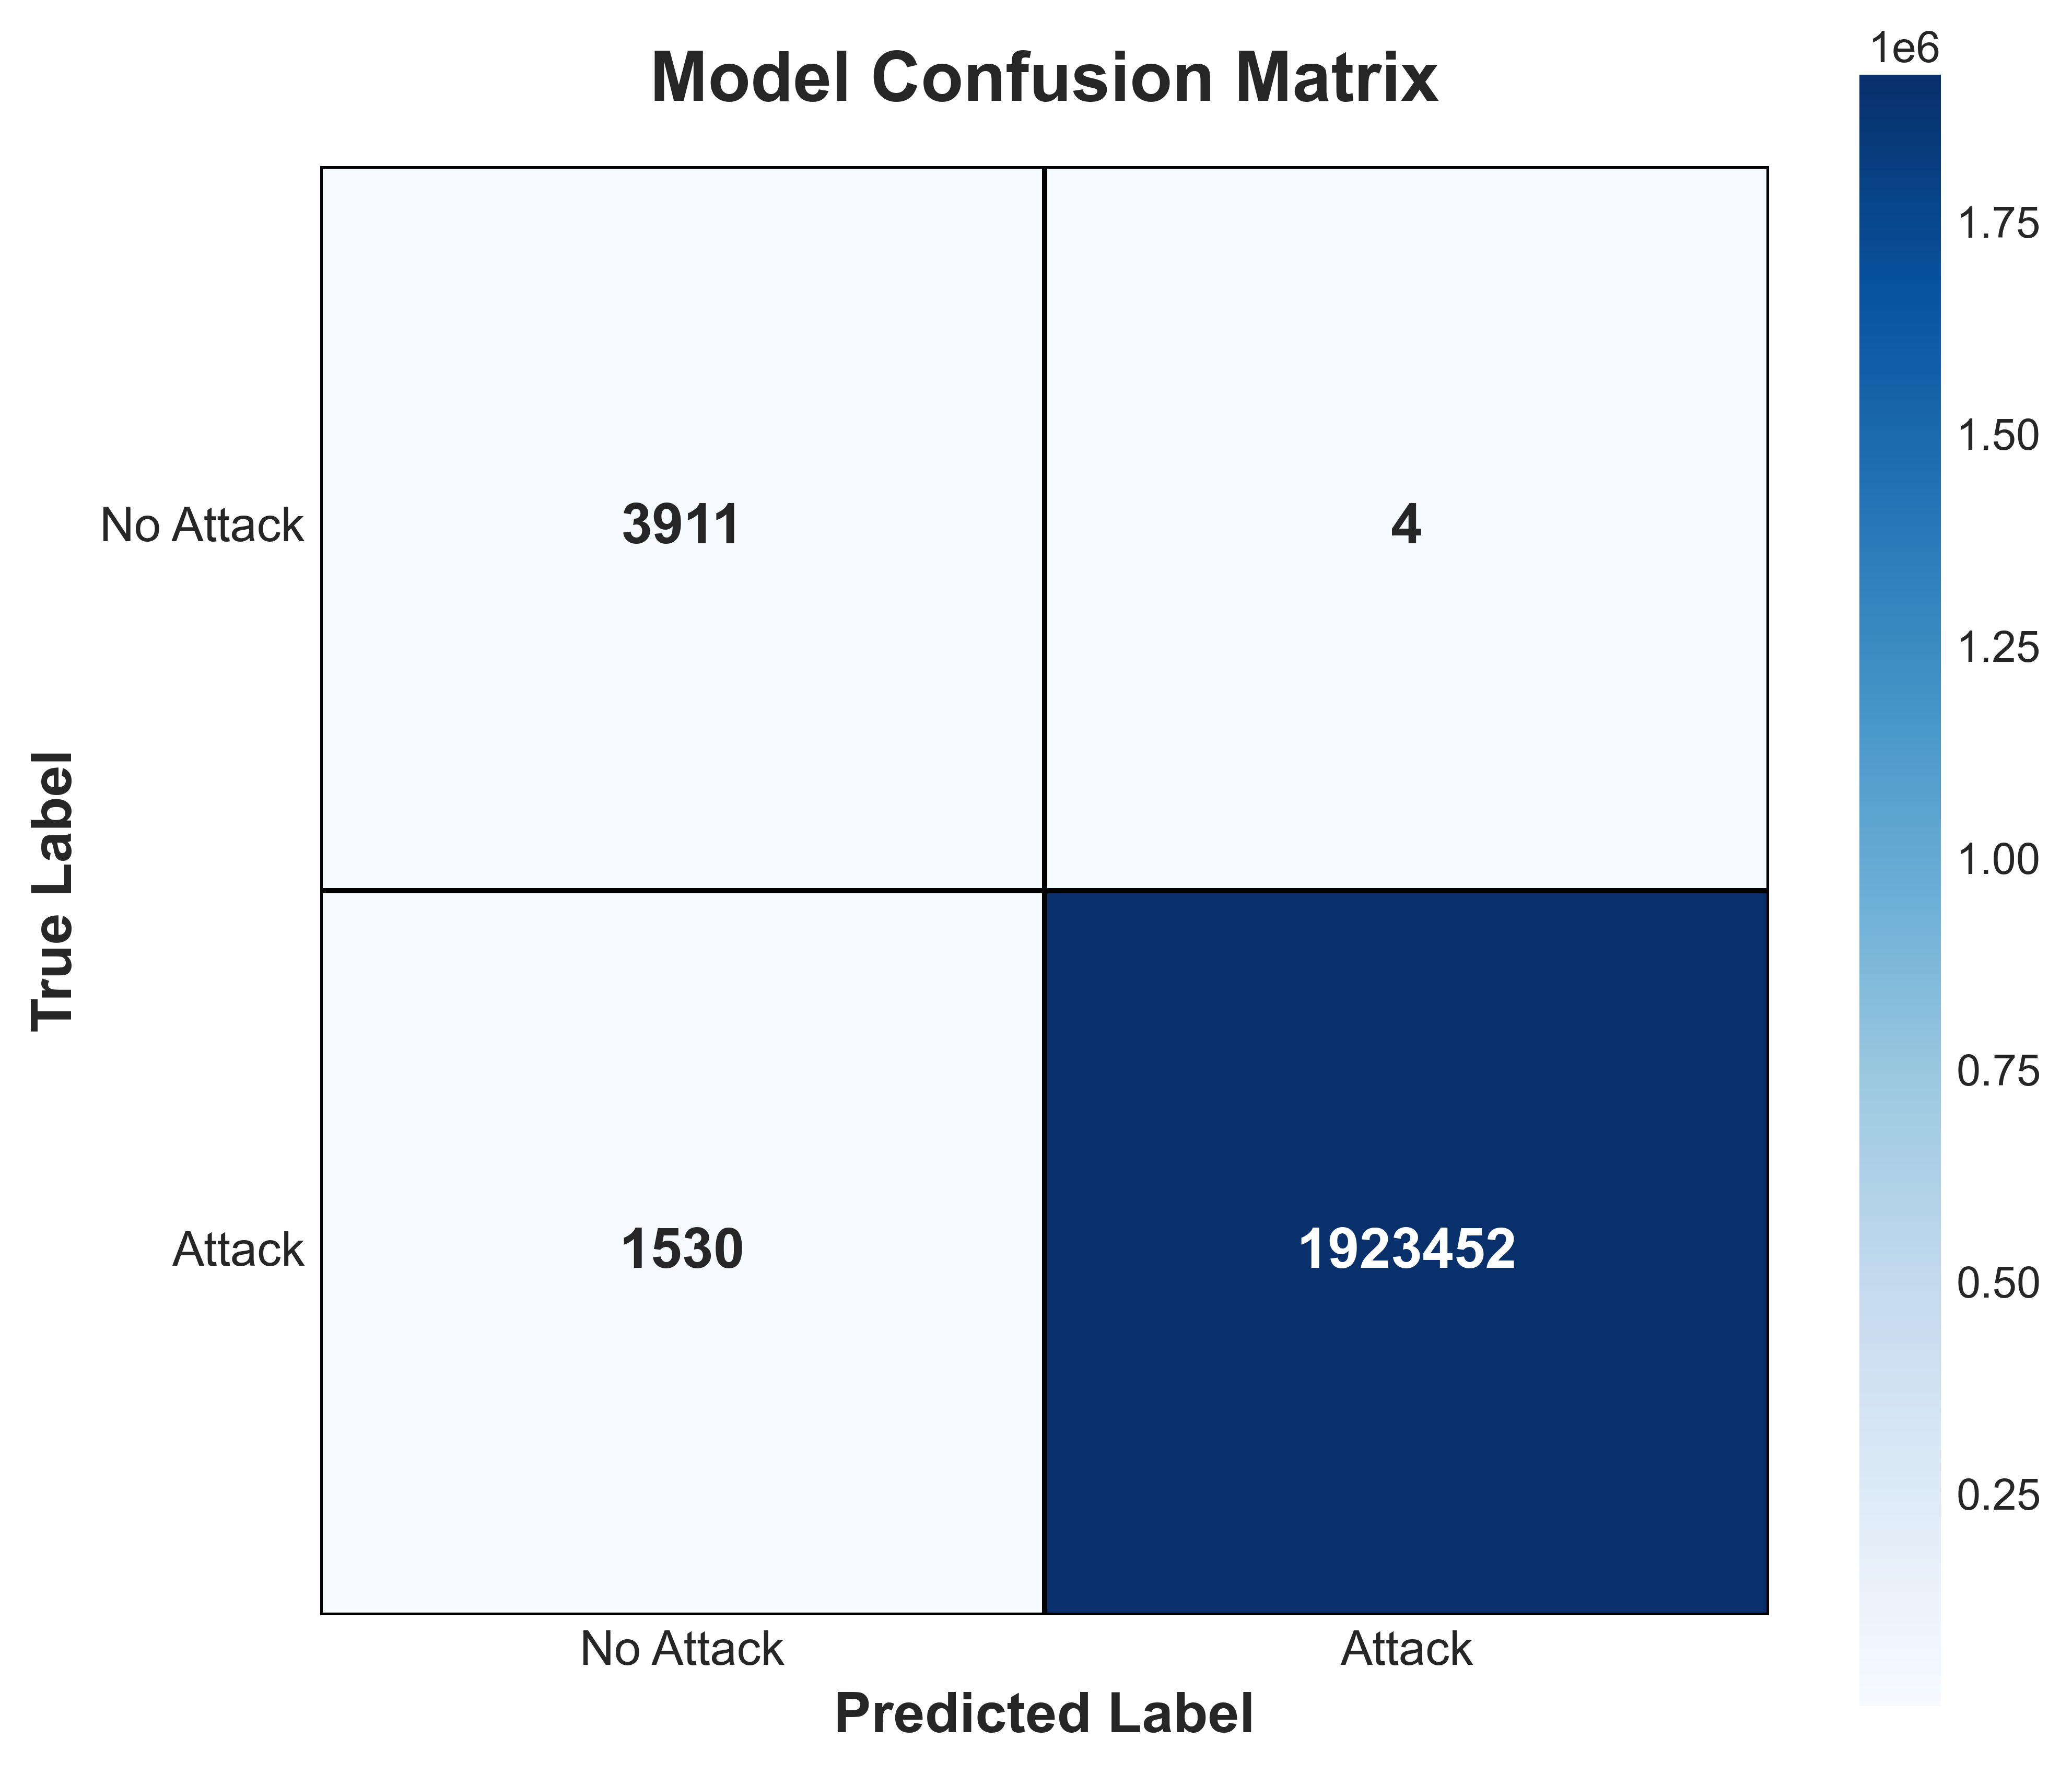

In [42]:
confusion_matrix_heatmap(y_test, y_pred)

In [43]:
results = {

    "accuracy": float(
        accuracy_score(y_test, y_pred)
    ),

    "precision": float(
        precision_score(y_test, y_pred)
    ),

    "recall": float(
        recall_score(y_test, y_pred)
    ),

    "f1_score": float(
        f1_score(y_test, y_pred)
    ),

    "auc": float(
        tf.keras.metrics.AUC()(
            y_test,
            y_pred_probs
        ).numpy()
    ),

    "inference_time_ms": avg_inference_time_ms,

    "confusion_matrix": confusion_matrix(
        y_test,
        y_pred
    ).tolist(),

    "classification_report": classification_report(
        y_test,
        y_pred,
        output_dict=True
    )
}

### **Export results in json format**

In [44]:
os.makedirs("results", exist_ok=True)

# Export path
results_path = os.path.join(
    "results",
    "evaluation_results_optuna.json"
)

# Save results
with open(results_path, "w") as f:
    json.dump(
        results,
        f,
        indent=4
    )

print(f"Results exported to: {results_path}")

Results exported to: results\evaluation_results_optuna.json
